In [1]:
!pip install albumentations

In [2]:
#필요한 라이브러리를 로드합니다.
import os
import math
import numpy as np
import torch
import torchvision.transforms as transforms

from PIL import Image
import matplotlib.pyplot as plt
from skimage.io import imread
from skimage.transform import resize
from glob import glob

import torch.nn as nn
import torch.optim as optim

print('=3')

=3


In [3]:
from albumentations import  HorizontalFlip, RandomSizedCrop, Compose, OneOf, Resize

def build_augmentation(is_train=True):
  if is_train:    # 훈련용 데이터일 경우
    return Compose([
                    HorizontalFlip(p=0.5),    # 50%의 확률로 좌우대칭
                    RandomSizedCrop(         # 50%의 확률로 RandomSizedCrop
                        min_max_height=(300, 370),
                        w2h_ratio=370/1242,
                        height=224,
                        width=224,
                        size=(224, 224),
                        p=0.5
                        ),
                    Resize(              # 입력이미지를 224X224로 resize
                        width=224,
                        height=224
                        )
                    ])
  return Compose([      # 테스트용 데이터일 경우에는 224X224로 resize만 수행합니다.
                Resize(
                    width=224,
                    height=224
                    )
                ])

/tmp/ipykernel_183/2497950994.py:7: UserWarning: Argument(s) 'height, width' are not valid for transform RandomSizedCrop
  RandomSizedCrop(         # 50%의 확률로 RandomSizedCrop


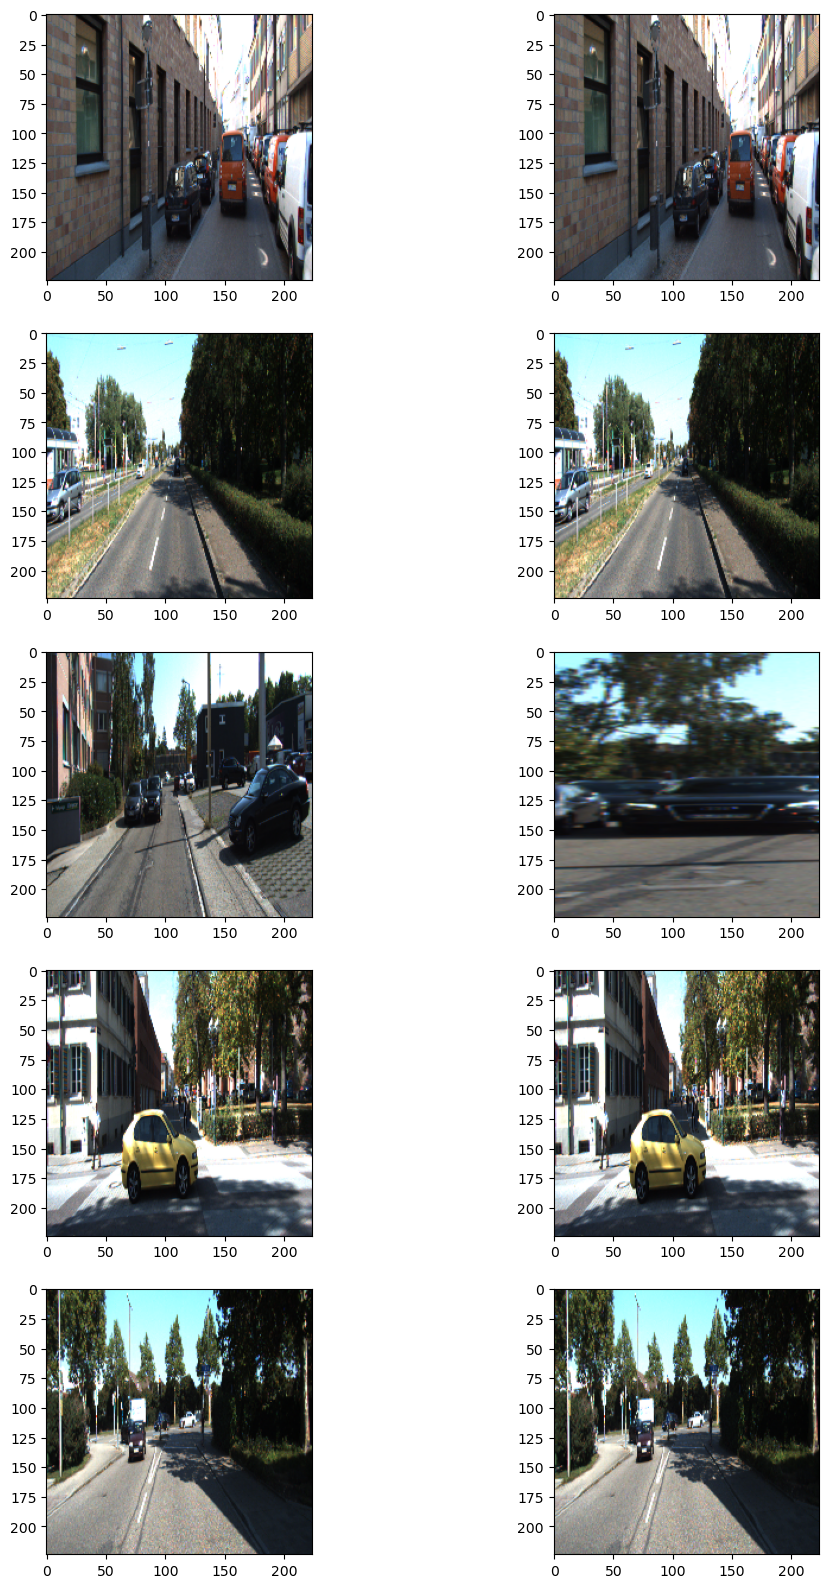

In [4]:
data_dir = os.path.join(os.getenv("HOME"), "work/semantic_segmentation/data/training")

augmentation_train = build_augmentation()
augmentation_test = build_augmentation(is_train=False)
input_images = glob(os.path.join(data_dir, "image_2", "*.png"))

# 훈련 데이터셋에서 5개만 가져와 augmentation을 적용해 봅시다.
plt.figure(figsize=(12, 20))
for i in range(5):
    image = imread(input_images[i])
    image_data = {"image":image}
    resized = augmentation_test(**image_data)
    processed = augmentation_train(**image_data)
    plt.subplot(5, 2, 2*i+1)
    plt.imshow(resized["image"])  # 왼쪽이 원본이미지
    plt.subplot(5, 2, 2*i+2)
    plt.imshow(processed["image"])  # 오른쪽이 augment된 이미지

plt.show()

In [5]:
from torch.utils.data import Dataset

class KittiDataset(Dataset):
    '''
    KittiDataset은 PyTorch의 Dataset을 상속받습니다.
    우리가 KittiDataset을 원하는 방식으로 preprocess하기 위해서 Dataset을 커스텀하여 사용합니다.
    '''
    def __init__(self,
                 dir_path,
                 img_size=(224, 224, 3),
                 output_size=(224, 224),
                 is_train=True,
                 augmentation=None):
        '''
        dir_path: dataset의 directory path입니다.
        img_size: preprocess에 사용할 입력이미지의 크기입니다.
        output_size: ground_truth를 만들어주기 위한 크기입니다.
        is_train: 이 Dataset이 학습용인지 테스트용인지 구분합니다.
        augmentation: 적용하길 원하는 augmentation 함수를 인자로 받습니다.
        '''
        self.dir_path = dir_path
        self.is_train = is_train
        self.augmentation = augmentation
        self.img_size = img_size
        self.output_size = output_size

        # load_dataset()을 통해 kitti dataset의 경로에서 라벨과 이미지를 확인합니다.
        self.data = self.load_dataset()

    def load_dataset(self):
        # kitti dataset에서 필요한 정보(이미지 경로 및 라벨)를 directory에서 확인하고 로드하는 함수입니다.
        input_images = sorted(glob(os.path.join(self.dir_path, "image_2", "*.png")))
        label_images = sorted(glob(os.path.join(self.dir_path, "semantic", "*.png")))

        assert len(input_images) == len(label_images)
        data = list(zip(input_images, label_images))

        if self.is_train:
            return data[:-30]
        return data[-30:]

    def __len__(self):
        # Dataset의 length로서 전체 dataset 크기를 반환합니다.
        return len(self.data)

    def __getitem__(self, index):
        # 입력과 출력을 만듭니다.
        # 입력은 resize 및 augmentation이 적용된 input image이고
        # 출력은 semantic label입니다.
        input_img_path, output_path = self.data[index]

        _input = imread(input_img_path)
        _output = imread(output_path)

        # 특정 라벨을 이진 마스크로 변환
        _output = (_output == 7).astype(np.uint8) * 1

        data = {
            "image": _input,
            "mask": _output,
        }

        if self.augmentation:
            augmented = self.augmentation(**data)
            _input = augmented["image"] / 255.0  # Normalize
            _output = augmented["mask"]

        # 📌 target 차원 확장 (H, W) → (1, H, W)
        _output = np.expand_dims(_output, axis=0)

        return (
            torch.tensor(_input, dtype=torch.float32).permute(2, 0, 1),  # (H, W, C) → (C, H, W)
            torch.tensor(_output, dtype=torch.float32)  # (1, H, W) 형식 유지
        )

    def shuffle_data(self):
        # 한 epoch가 끝나면 실행되는 함수입니다. 학습 중인 경우에 데이터를 random shuffle합니다.
        if self.is_train:
            np.random.shuffle(self.data)

In [6]:
from torch.utils.data import DataLoader

# Augmentation 설정
augmentation = build_augmentation()
test_preproc = build_augmentation(is_train=False)

train_dataset = KittiDataset(
    data_dir,
    augmentation=augmentation,
    is_train=True
)

test_dataset = KittiDataset(
    data_dir,
    augmentation=test_preproc,
    is_train=False
)

# DataLoader 설정
train_loader = DataLoader(train_dataset, batch_size=16, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=16, shuffle=False)

/tmp/ipykernel_183/2497950994.py:7: UserWarning: Argument(s) 'height, width' are not valid for transform RandomSizedCrop
  RandomSizedCrop(         # 50%의 확률로 RandomSizedCrop


In [7]:
import torch.nn.functional as F

class UNet(nn.Module):
    def __init__(self, input_channels=3, output_channels=1):
        super(UNet, self).__init__()

        # Contracting Path (Encoder)
        self.enc1 = self.double_conv(input_channels, 64)
        self.pool1 = nn.MaxPool2d(2)
        self.enc2 = self.double_conv(64, 128)
        self.pool2 = nn.MaxPool2d(2)
        self.enc3 = self.double_conv(128, 256)
        self.pool3 = nn.MaxPool2d(2)
        self.enc4 = self.double_conv(256, 512)
        self.pool4 = nn.MaxPool2d(2)

        # Bottleneck
        self.bottleneck = self.double_conv(512, 1024)
        self.dropout = nn.Dropout(0.5)

        # Expanding Path (Decoder)
        self.up6 = nn.ConvTranspose2d(1024, 512, kernel_size=2, stride=2)
        self.dec6 = self.double_conv(1024, 512)
        self.up7 = nn.ConvTranspose2d(512, 256, kernel_size=2, stride=2)
        self.dec7 = self.double_conv(512, 256)
        self.up8 = nn.ConvTranspose2d(256, 128, kernel_size=2, stride=2)
        self.dec8 = self.double_conv(256, 128)
        self.up9 = nn.ConvTranspose2d(128, 64, kernel_size=2, stride=2)
        self.dec9 = self.double_conv(128, 64)

        # Output layer
        self.final = nn.Conv2d(64, output_channels, kernel_size=1)

    def double_conv(self, in_channels, out_channels):
        """2개의 Conv Layer로 이루어진 블록"""
        return nn.Sequential(
            nn.Conv2d(in_channels, out_channels, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),
            nn.Conv2d(out_channels, out_channels, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),
        )

    def forward(self, x):
        # Encoder
        c1 = self.enc1(x)
        p1 = self.pool1(c1)
        c2 = self.enc2(p1)
        p2 = self.pool2(c2)
        c3 = self.enc3(p2)
        p3 = self.pool3(c3)
        c4 = self.enc4(p3)
        p4 = self.pool4(c4)

        # Bottleneck
        c5 = self.bottleneck(p4)
        c5 = self.dropout(c5)

        # Decoder
        u6 = self.up6(c5)
        u6 = torch.cat([u6, c4], dim=1)
        c6 = self.dec6(u6)

        u7 = self.up7(c6)
        u7 = torch.cat([u7, c3], dim=1)
        c7 = self.dec7(u7)

        u8 = self.up8(c7)
        u8 = torch.cat([u8, c2], dim=1)
        c8 = self.dec8(u8)

        u9 = self.up9(c8)
        u9 = torch.cat([u9, c1], dim=1)
        c9 = self.dec9(u9)

        # Output
        output = torch.sigmoid(self.final(c9))
        return output

In [8]:
%%time

# 모델 저장 경로
model_path = "./seg_model_unet.pth"

# 모델 생성
model = UNet(input_channels=3, output_channels=1)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)

# 손실 함수 및 옵티마이저 설정
criterion = torch.nn.BCELoss()
optimizer = optim.Adam(model.parameters(), lr=1e-4)

# 데이터로더 준비
train_loader = DataLoader(train_dataset, batch_size=16, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=16, shuffle=False)

# 모델 학습
num_epochs = 100
for epoch in range(num_epochs):
    model.train()
    running_loss = 0.0
    for inputs, targets in train_loader:
        inputs, targets = inputs.to(device), targets.to(device)

        optimizer.zero_grad()
        outputs = model(inputs)
        loss = criterion(outputs, targets.float())  # 타겟을 float 타입으로 변환
        loss.backward()
        optimizer.step()

        running_loss += loss.item()

    print(f"Epoch {epoch+1}/{num_epochs}, Loss: {running_loss/len(train_loader)}")

# 모델 저장
save_dir = os.path.dirname(model_path)
if not os.path.exists(save_dir):
    os.makedirs(save_dir, exist_ok=True)
    print(f"폴더를 생성했습니다: {save_dir}")
    
torch.save(model.state_dict(), model_path)

Epoch 1/100, Loss: 0.6633701649579135
Epoch 2/100, Loss: 0.6290141344070435
Epoch 3/100, Loss: 0.5350274443626404
Epoch 4/100, Loss: 0.5105613578449596
Epoch 5/100, Loss: 0.4151868359609084
Epoch 6/100, Loss: 0.3619529902935028
Epoch 7/100, Loss: 0.3192708492279053
Epoch 8/100, Loss: 0.2831369218501178
Epoch 9/100, Loss: 0.26016866754401813
Epoch 10/100, Loss: 0.2374038885940205
Epoch 11/100, Loss: 0.2331722012974999
Epoch 12/100, Loss: 0.2140010730786757
Epoch 13/100, Loss: 0.20940028401938351
Epoch 14/100, Loss: 0.22835774855180221
Epoch 15/100, Loss: 0.21487001939253372
Epoch 16/100, Loss: 0.2447181222113696
Epoch 17/100, Loss: 0.20974617925557223
Epoch 18/100, Loss: 0.24355834993449124
Epoch 19/100, Loss: 0.20829530602151697
Epoch 20/100, Loss: 0.19672253050587393
Epoch 21/100, Loss: 0.1749300780621442
Epoch 22/100, Loss: 0.1848445168950341
Epoch 23/100, Loss: 0.18621409210291776
Epoch 24/100, Loss: 0.18017235127362338
Epoch 25/100, Loss: 0.1632799899036234
Epoch 26/100, Loss: 0.18

In [9]:
model = UNet(input_channels=3, output_channels=1)
model.load_state_dict(torch.load(model_path, map_location=torch.device('cpu')))
model.eval()  # 평가 모드로 전환

UNet(
  (enc1): Sequential(
    (0): Conv2d(3, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU(inplace=True)
    (2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (3): ReLU(inplace=True)
  )
  (pool1): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (enc2): Sequential(
    (0): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU(inplace=True)
    (2): Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (3): ReLU(inplace=True)
  )
  (pool2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (enc3): Sequential(
    (0): Conv2d(128, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU(inplace=True)
    (2): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (3): ReLU(inplace=True)
  )
  (pool3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (enc4): Sequential(
    (0): Con

In [10]:
import matplotlib.pyplot as plt

def get_output(model, preproc, image_path, output_path):
    # 원본 이미지 로드
    origin_img = imread(image_path)
    data = {"image": origin_img}

    # 전처리 적용
    processed = preproc(**data)
    input_tensor = torch.tensor(processed["image"] / 255.0, dtype=torch.float32).permute(2, 0, 1).unsqueeze(0)

    # 모델 추론 (inference)
    model.eval()
    with torch.no_grad():
        output = model(input_tensor)

    # 시그모이드 활성화 후 임계값(0.5) 적용하여 바이너리 마스크 생성
    output = (output[0].squeeze().numpy() > 0.5).astype(np.uint8) * 255   #0.5라는 threshold를 변경하면 도로인식 결과범위가 달라집니다.
    output = Image.fromarray(output)

    # 배경과 결합하여 시각화 (Overlay)
    background = Image.fromarray(origin_img).convert('RGBA')
    output = output.resize((origin_img.shape[1], origin_img.shape[0])).convert('RGBA')
    blended = Image.blend(background, output, alpha=0.5)

    # 변환된 이미지 저장
    blended.save(output_path)

    # PIL 객체를 numpy로 변환
    img_np = np.array(blended)

    # 시각화
    plt.imshow(img_np)
    plt.axis('off')  # 축 제거 (옵션)
    plt.show()

    # blended.show()
    return blended

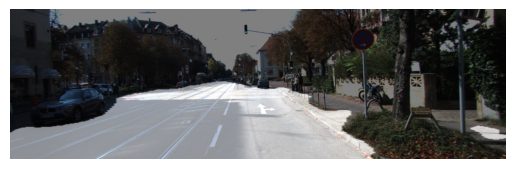

(<PIL.Image.Image image mode=RGBA size=1242x375>,
 array([[  0,   0,   0, ...,   0,   0,   0],
        [  0,   0,   0, ...,   0,   0,   0],
        [  0,   0,   0, ...,   0,   0,   0],
        ...,
        [255, 255, 255, ...,   0,   0,   0],
        [255, 255, 255, ...,   0,   0,   0],
        [255, 255, 255, ...,   0,   0,   0]], shape=(224, 224), dtype=uint8),
 None)

In [19]:
# 완성한 뒤에는 시각화한 결과를 눈으로 확인해봅시다!
dir_path = './data/training'

i = 1    # i값을 바꾸면 테스트용 파일이 달라집니다.
get_output(
     model,
     test_preproc,
     image_path=dir_path + f'/image_2/00{str(i).zfill(4)}_10.png',
     output_path=dir_path + f'/result_{str(i).zfill(3)}.png'
 )

In [20]:
def calculate_iou_score(target, prediction):
    if target.shape != prediction.shape:
        prediction = resize(prediction, target.shape, mode='constant', preserve_range=True).astype(np.uint8)

    intersection = np.logical_and(target, prediction).sum() # intersection을 구하는 코드를 작성해주세요.
    union = np.logical_or(target, prediction).sum() # intersection을 구하는 코드를 작성해주세요.
    iou_score = intersection / (union + 1e-7)  # iou 스코어를 구하되 결과값을 float로 만들어주세요!
    print(f"IoU : {iou_score:.6f}")
    return iou_score

In [21]:
def get_output(model, preproc, image_path, output_path, label_path=None):
    origin_img = imread(image_path)
    data = {"image": origin_img}
    processed = preproc(**data)
    input_tensor = torch.tensor(processed["image"] / 255.0, dtype=torch.float32)
    input_tensor = input_tensor.permute(2, 0, 1).unsqueeze(0)

    model.eval()
    with torch.no_grad():
        output = model(input_tensor)

    prediction = (output[0].squeeze().numpy() > 0.5).astype(np.uint8) * 255
    prediction = Image.fromarray(prediction).convert('L')

    background = Image.fromarray(origin_img).convert('RGBA')
    prediction_resized = prediction.resize((origin_img.shape[1], origin_img.shape[0])).convert('RGBA')
    blended = Image.blend(background, prediction_resized, alpha=0.5)

    blended.save(output_path)
    # PIL 객체를 numpy로 변환
    img_np = np.array(blended)

    # 시각화
    plt.imshow(img_np)
    plt.axis('off')  # 축 제거 (옵션)
    plt.show()

    target = None
    if label_path:
        label_img = imread(label_path)
        label_data = {"image": label_img}
        label_processed = preproc(**label_data)["image"]
        target = (label_processed == 7).astype(np.uint8) * 1

    return blended, np.array(prediction), target

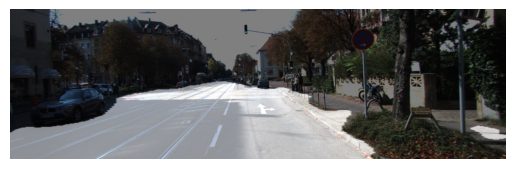

IoU : 0.874777


np.float64(0.8747771518157685)

In [22]:
# 완성한 뒤에는 시각화한 결과를 눈으로 확인해봅시다!
i = 1    # i값을 바꾸면 테스트용 파일이 달라집니다.
output, prediction, target = get_output(
     model,
     test_preproc,
     image_path=dir_path + f'/image_2/00{str(i).zfill(4)}_10.png',
     output_path=dir_path + f'/result_{str(i).zfill(3)}.png',
     label_path=dir_path + f'/semantic/00{str(i).zfill(4)}_10.png'
 )

calculate_iou_score(target, prediction)

In [23]:
import torch
import torch.nn as nn

class BCEDiceLoss(nn.Module):
    def __init__(self):
        super(BCEDiceLoss, self).__init__()
        self.bce = nn.BCELoss()

    def forward(self, inputs, targets):
        # 1. BCE Loss 계산
        bce_loss = self.bce(inputs, targets)
        
        # 2. Dice Loss 계산
        smooth = 1e-5
        inputs_flat = inputs.view(-1)
        targets_flat = targets.view(-1)
        
        intersection = (inputs_flat * targets_flat).sum()
        dice_coef = (2. * intersection + smooth) / (inputs_flat.sum() + targets_flat.sum() + smooth)
        dice_loss = 1 - dice_coef
        
        # 3. 최종 Loss
        return bce_loss + dice_loss

print("✅ BCEDiceLoss 정의 완료!")

✅ BCEDiceLoss 정의 완료!


In [24]:
class VGGBlock(nn.Module):
    def __init__(self, in_channels, middle_channels, out_channels):
        super().__init__()
        self.relu = nn.ReLU(inplace=True)
        self.conv1 = nn.Conv2d(in_channels, middle_channels, 3, padding=1)
        self.bn1 = nn.BatchNorm2d(middle_channels)
        self.conv2 = nn.Conv2d(middle_channels, out_channels, 3, padding=1)
        self.bn2 = nn.BatchNorm2d(out_channels)

    def forward(self, x):
        out = self.conv1(x)
        out = self.bn1(out)
        out = self.relu(out)
        out = self.conv2(out)
        out = self.bn2(out)
        out = self.relu(out)
        return out

class UNetPlusPlus(nn.Module):
    def __init__(self, input_channels=3, output_channels=1):
        super().__init__()
        # VRAM 메모리 절약을 위해 필터 개수를 조금 조절했습니다.
        nb_filter = [32, 64, 128, 256, 512]

        self.pool = nn.MaxPool2d(2, 2)
        self.up = nn.Upsample(scale_factor=2, mode='bilinear', align_corners=True)

        # 인코더 부분
        self.conv0_0 = VGGBlock(input_channels, nb_filter[0], nb_filter[0])
        self.conv1_0 = VGGBlock(nb_filter[0], nb_filter[1], nb_filter[1])
        self.conv2_0 = VGGBlock(nb_filter[1], nb_filter[2], nb_filter[2])
        self.conv3_0 = VGGBlock(nb_filter[2], nb_filter[3], nb_filter[3])
        self.conv4_0 = VGGBlock(nb_filter[3], nb_filter[4], nb_filter[4])

        # Dense 스킵 연결 부분 (U-Net++)
        self.conv0_1 = VGGBlock(nb_filter[0]+nb_filter[1], nb_filter[0], nb_filter[0])
        self.conv1_1 = VGGBlock(nb_filter[1]+nb_filter[2], nb_filter[1], nb_filter[1])
        self.conv2_1 = VGGBlock(nb_filter[2]+nb_filter[3], nb_filter[2], nb_filter[2])
        self.conv3_1 = VGGBlock(nb_filter[3]+nb_filter[4], nb_filter[3], nb_filter[3])

        self.conv0_2 = VGGBlock(nb_filter[0]*2+nb_filter[1], nb_filter[0], nb_filter[0])
        self.conv1_2 = VGGBlock(nb_filter[1]*2+nb_filter[2], nb_filter[1], nb_filter[1])
        self.conv2_2 = VGGBlock(nb_filter[2]*2+nb_filter[3], nb_filter[2], nb_filter[2])

        self.conv0_3 = VGGBlock(nb_filter[0]*3+nb_filter[1], nb_filter[0], nb_filter[0])
        self.conv1_3 = VGGBlock(nb_filter[1]*3+nb_filter[2], nb_filter[1], nb_filter[1])

        self.conv0_4 = VGGBlock(nb_filter[0]*4+nb_filter[1], nb_filter[0], nb_filter[0])

        self.final = nn.Conv2d(nb_filter[0], output_channels, kernel_size=1)

    def forward(self, input):
        x0_0 = self.conv0_0(input)
        x1_0 = self.conv1_0(self.pool(x0_0))
        x0_1 = self.conv0_1(torch.cat([x0_0, self.up(x1_0)], 1))

        x2_0 = self.conv2_0(self.pool(x1_0))
        x1_1 = self.conv1_1(torch.cat([x1_0, self.up(x2_0)], 1))
        x0_2 = self.conv0_2(torch.cat([x0_0, x0_1, self.up(x1_1)], 1))

        x3_0 = self.conv3_0(self.pool(x2_0))
        x2_1 = self.conv2_1(torch.cat([x2_0, self.up(x3_0)], 1))
        x1_2 = self.conv1_2(torch.cat([x1_0, x1_1, self.up(x2_1)], 1))
        x0_3 = self.conv0_3(torch.cat([x0_0, x0_1, x0_2, self.up(x1_2)], 1))

        x4_0 = self.conv4_0(self.pool(x3_0))
        x3_1 = self.conv3_1(torch.cat([x3_0, self.up(x4_0)], 1))
        x2_2 = self.conv2_2(torch.cat([x2_0, x2_1, self.up(x3_1)], 1))
        x1_3 = self.conv1_3(torch.cat([x1_0, x1_1, x1_2, self.up(x2_2)], 1))
        x0_4 = self.conv0_4(torch.cat([x0_0, x0_1, x0_2, x0_3, self.up(x1_3)], 1))

        output = torch.sigmoid(self.final(x0_4))
        return output

print("✅ U-Net++ 아키텍처 정의 완료!")

✅ U-Net++ 아키텍처 정의 완료!


In [25]:
import torch.optim as optim
from torch.utils.data import DataLoader
import time

# ⚠️ U-Net++ 메모리 최적화를 위해 배치 사이즈를 절반(8)으로 조정합니다.
train_loader_plus = DataLoader(train_dataset, batch_size=8, shuffle=True)

# 모델, 손실함수, 옵티마이저 선언
model_plus = UNetPlusPlus(input_channels=3, output_channels=1)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model_plus.to(device)

criterion_plus = BCEDiceLoss() # 방금 만든 새로운 손실함수 적용
optimizer_plus = optim.Adam(model_plus.parameters(), lr=1e-4)

# 학습 진행 (시간 관계상 적절한 에폭 수로 조절 가능합니다. 예: 20~30)
num_epochs_plus = 20  
print("🚀 U-Net++ 학습을 시작합니다...")

for epoch in range(num_epochs_plus):
    model_plus.train()
    running_loss = 0.0
    for inputs, targets in train_loader_plus:
        inputs, targets = inputs.to(device), targets.to(device)

        optimizer_plus.zero_grad()
        outputs = model_plus(inputs)
        
        loss = criterion_plus(outputs, targets.float()) 
        loss.backward()
        optimizer_plus.step()

        running_loss += loss.item()

    print(f"U-Net++ Epoch {epoch+1}/{num_epochs_plus}, Loss: {running_loss/len(train_loader_plus):.4f}")

# 모델 저장
model_path_plus = "./seg_model_unet_plus_plus.pth"
torch.save(model_plus.state_dict(), model_path_plus)
print(f"💾 U-Net++ 모델 저장 완료: {model_path_plus}")

🚀 U-Net++ 학습을 시작합니다...
U-Net++ Epoch 1/20, Loss: 1.0240
U-Net++ Epoch 2/20, Loss: 0.8250
U-Net++ Epoch 3/20, Loss: 0.8095
U-Net++ Epoch 4/20, Loss: 0.7570
U-Net++ Epoch 5/20, Loss: 0.7625
U-Net++ Epoch 6/20, Loss: 0.6991
U-Net++ Epoch 7/20, Loss: 0.6705
U-Net++ Epoch 8/20, Loss: 0.6716
U-Net++ Epoch 9/20, Loss: 0.7315
U-Net++ Epoch 10/20, Loss: 0.6523
U-Net++ Epoch 11/20, Loss: 0.6901
U-Net++ Epoch 12/20, Loss: 0.6338
U-Net++ Epoch 13/20, Loss: 0.6114
U-Net++ Epoch 14/20, Loss: 0.6009
U-Net++ Epoch 15/20, Loss: 0.6025
U-Net++ Epoch 16/20, Loss: 0.5814
U-Net++ Epoch 17/20, Loss: 0.5680
U-Net++ Epoch 18/20, Loss: 0.5699
U-Net++ Epoch 19/20, Loss: 0.5609
U-Net++ Epoch 20/20, Loss: 0.5437
💾 U-Net++ 모델 저장 완료: ./seg_model_unet_plus_plus.pth


📸 모델 비교 시각화 출력중...


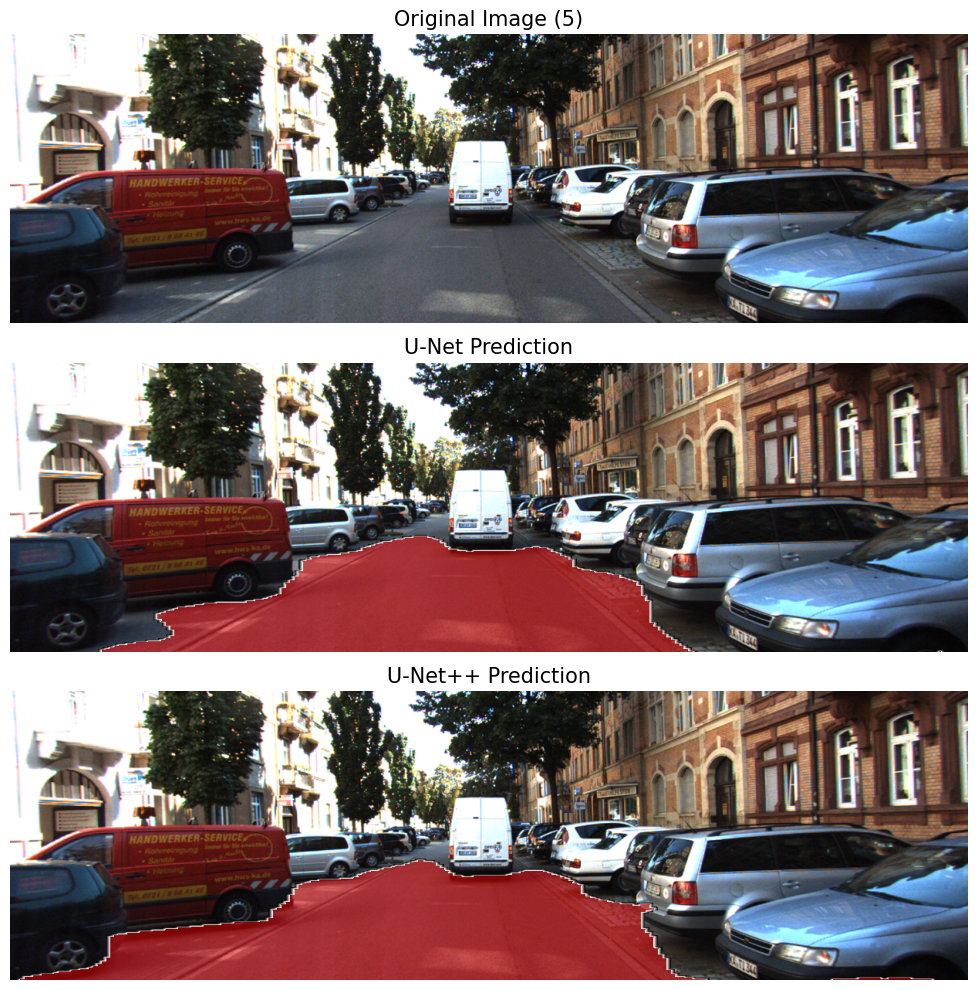

In [30]:
import matplotlib.pyplot as plt
import numpy as np
from PIL import Image
from skimage.io import imread

def compare_models_visually(img_index, unet_model, unet_plus_model, preproc, dir_path):
    # 1. 이미지 로드 및 전처리
    image_path = dir_path + f'/image_2/00{str(img_index).zfill(4)}_10.png'
    origin_img = imread(image_path)
    
    data = {"image": origin_img}
    processed = preproc(**data)
    input_tensor = torch.tensor(processed["image"] / 255.0, dtype=torch.float32).permute(2, 0, 1).unsqueeze(0).to(device)

    # 2. 두 모델 Inference
    unet_model.eval()
    unet_plus_model.eval()
    with torch.no_grad():
        out_unet = unet_model(input_tensor)
        out_plus = unet_plus_model(input_tensor)

    # 3. 마스크 생성 및 오버레이 (Threshold 0.5)
    def create_overlay(out_tensor):
        mask = (out_tensor[0].squeeze().cpu().numpy() > 0.5).astype(np.uint8) * 255
        mask_img = Image.fromarray(mask).resize((origin_img.shape[1], origin_img.shape[0])).convert('RGBA')
        bg = Image.fromarray(origin_img).convert('RGBA')
        
        # 도로 부분만 색칠하기 위해 검은색 배경 투명하게 처리 (선택적 가시성 향상)
        mask_data = np.array(mask_img)
        mask_data[(mask_data[:,:,0] == 0)] = [0, 0, 0, 0] # 검은색은 투명하게
        mask_data[(mask_data[:,:,0] == 255)] = [255, 0, 0, 120] # 도로는 빨간색 반투명
        
        color_mask = Image.fromarray(mask_data)
        return Image.alpha_composite(bg, color_mask)

    overlay_unet = create_overlay(out_unet)
    overlay_plus = create_overlay(out_plus)

    # 4. Matplotlib을 이용한 1x3 시각화
    fig, axes = plt.subplots(3, 1, figsize=(30, 10))
    
    axes[0].imshow(origin_img)
    axes[0].set_title(f"Original Image ({img_index})", fontsize=15)
    axes[0].axis('off')
    
    axes[1].imshow(overlay_unet)
    axes[1].set_title("U-Net Prediction", fontsize=15)
    axes[1].axis('off')
    
    axes[2].imshow(overlay_plus)
    axes[2].set_title("U-Net++ Prediction", fontsize=15)
    axes[2].axis('off')
    
    plt.tight_layout()
    plt.show()

# ==========================================
# 실행 부분 (이전에 학습했던 기존 U-Net과 새로 만든 U-Net++ 모두 device에 올려서 넘겨줍니다)
# ==========================================

# 1. 기존 U-Net 가중치 로드
model.load_state_dict(torch.load(model_path, map_location=device))

# 2. ★★★ 두 모델 모두 명시적으로 GPU(device)로 이동 ★★★
model = model.to(device)
model_plus = model_plus.to(device)

# 테스트할 이미지 번호를 넣어 시각화해 보세요! (예: 1번, 5번, 10번 이미지)
print("📸 모델 비교 시각화 출력중...")
compare_models_visually(5, model, model_plus, test_preproc, dir_path)